In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
import unicodedata
import seaborn as sns

from unidecode import unidecode as _unidecode

In [46]:
nlp = spacy.load("pt_core_news_lg", disable=["ner", "parser"])

def normalize_unidecode(text: str) -> str:
    return _unidecode(text)

def base_clean_pt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text.strip()) # remove breaks and normalize spaces
    text = re.sub(r'<[^>]+>', '', text) # remove HTML, URLs, and emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = normalize_unidecode(text) # normalize accents
    text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text) # remove alphanumeric tokens of type Q12, A1, C3
    text = re.sub(r'[^\w\s\-\']', ' ', text) # remove loose punctuation (keep hyphens and apostrophes within words if they exist)
    text = re.sub(r'\s+', ' ', text).strip() # normalize spaces again
    return text.lower()

def spacy_process(texts, lemmatize = False, remove_stopwords = False, batch_size=512):
    cleaned = (base_clean_pt(t) for t in texts)
    results = []

    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for tok in doc:
            if tok.is_punct or tok.is_space or tok.like_num or len(tok.text) <= 2:
                continue
            if remove_stopwords and tok.is_stop:
                continue

            token = tok.lemma_ if lemmatize else tok.text
            tokens.append(token.lower())

        results.append(" ".join(tokens))

    return results

def data_preprocessing(df, column_name, sufix=""):
    df[f'UNCLEAN_TEXT{sufix}'] = (
        df[column_name]
        .fillna("")
        .astype(str)
    )

    df[f'BASE_TEXT{sufix}'] = spacy_process(
        df[f'UNCLEAN_TEXT{sufix}'],
        lemmatize=False,
        remove_stopwords=False
    )

    df[f'TEXT_NO_STOP{sufix}'] = spacy_process(
        df[f'UNCLEAN_TEXT{sufix}'],
        lemmatize=False,
        remove_stopwords=True
    )

    df[f'TEXT_LEMMA{sufix}'] = spacy_process(
        df[f'UNCLEAN_TEXT{sufix}'],
        lemmatize=True,
        remove_stopwords=False
    )

    df[f'CLEAN_TEXT{sufix}'] = spacy_process(
        df[f'UNCLEAN_TEXT{sufix}'],
        lemmatize=True,
        remove_stopwords=True
    )

    return df

# (1) TweetEmotionsPTBR

In [6]:
df = pd.read_excel('../data/03_TweetEmotionsPTBR.xlsx')
df.drop(columns=['alegria',	'tristeza',	'raiva', 'medo', 'nojo', 'surpresa', 'confianca', 'antecipacao'], inplace=True)
print(df.shape)
df.head(3)

(12678, 2)


,texto,sentimento
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção
2,"A franquia continua ativa, com o desenvolvimen...",decepção


In [7]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'texto')
df.rename(columns={"sentimento": 'EMOTION'}, inplace=True)
print(df.shape)
df.head(3)

(12420, 7)


,texto,EMOTION,UNCLEAN_TEXT,BASE_TEXT,TEXT_NO_STOP,TEXT_LEMMA,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,que jubilo incalculavel ver todos meus querido...,jubilo incalculavel queridos prestaram ano pas...,que jubilo incalculavel ver todo meu querido q...,jubilo incalculavel querido prestar ano passad...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",sapontamentoi senhor arranca meu coracao qualq...,sapontamentoi senhor arranca coracao desaponta...,sapontamentoir senhor arrancar meu coracao qua...,sapontamentoir senhor arrancar coracao desapon...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,"A franquia continua ativa, com o desenvolvimen...",franquia continua ativa com desenvolvimento jo...,franquia continua ativa desenvolvimento jogo p...,franquia continuar ativo com desenvolvimento j...,franquia continuar ativo desenvolvimento jogo ...


In [8]:
n_nan = df['BASE_TEXT'].isna().sum()

n_empty = (df['BASE_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['BASE_TEXT'])
df = df[df['BASE_TEXT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 1
Total problemáticos: 1
(12419, 7)


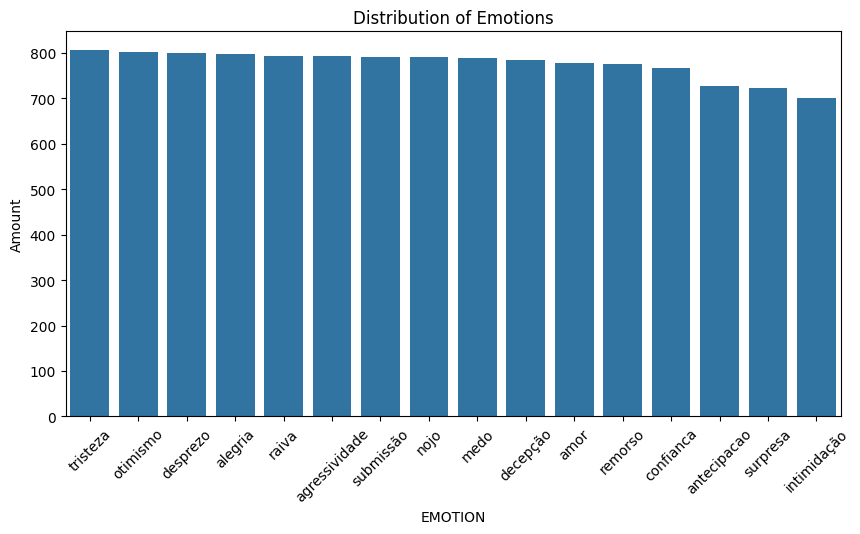

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

In [10]:
df.to_csv("../data/treated/tweet_emotions_ptbr_treated.csv", index=False)

# (2) GoEmotions

In [173]:
df_1 = pd.read_csv('../data/05_goemotions_1_pt.csv')
df_2 = pd.read_csv('../data/05_goemotions_2_pt.csv')
df_3 = pd.read_csv('../data/05_goemotions_3_pt.csv')

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['author', 'subreddit', 'link_id', 'parent_id', 'created_utc'], inplace=True)

print(df.shape)
df.head(3)

(211225, 33)


,text,id,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
0,That game hurt.,eew5j0j,1,False,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Aquele jogo doeu.
1,>sexuality shouldn’t be a grouping category I...,eemcysk,37,True,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...
2,"You do right, if you don't care then fuck 'em!",ed2mah1,37,False,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ..."


In [174]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

for c in emotion_cols:
    df[c] = (
        df.groupby('id')[c]
        .transform('sum')
        .ge(2)
        .astype(int)
    )

df['label_sum'] = df[emotion_cols].sum(axis=1)
df = df[df['label_sum'] > 0]

df = (
    df
    .groupby('id', as_index=False)
    .agg(
        {
            **{c: 'max' for c in emotion_cols},
            'text': 'first',
            'texto': 'first'
        }
    )
)

print(df.shape)  # ~54k

(54263, 31)


In [175]:
conflicts = (
    df
    .groupby('id')[emotion_cols]
    .nunique()
    .max(axis=1)
)

(conflicts > 1).sum()

np.int64(0)

In [176]:
df.columns

Index(['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral',
       'text', 'texto'],
      dtype='object')

In [177]:
df = data_preprocessing(df, 'texto', '_PT')
df = data_preprocessing(df, 'text', '_EN')

print(df.shape)
df.head(3)

(54263, 41)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,UNCLEAN_TEXT_PT,BASE_TEXT_PT,TEXT_NO_STOP_PT,TEXT_LEMMA_PT,CLEAN_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN,TEXT_NO_STOP_EN,TEXT_LEMMA_EN,CLEAN_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,tao rapido nome carregara seriamente uptown ce...,tao rapido quanto nome carregar seriamente upt...,tao rapido nome carregar seriamente uptown cen...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,voce estragou tocaram voce violino,voce estragar isso eles tocar voce como violino,voce estragar tocar voce violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,nao super bowls name prepare-se temporada vito...,nao mais super bowl para name preparar se para...,nao super bowl name preparar se temporada vito...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...,more superbowls name get ready another winning...,more superbowls ser name get ready ser another...,more superbowls name get ready another winning...


In [178]:
n_nan = df['BASE_TEXT_PT'].isna().sum()

n_empty = (df['BASE_TEXT_PT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['BASE_TEXT_PT'])
df = df[df['BASE_TEXT_PT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 29
Total problemáticos: 29
(54234, 41)


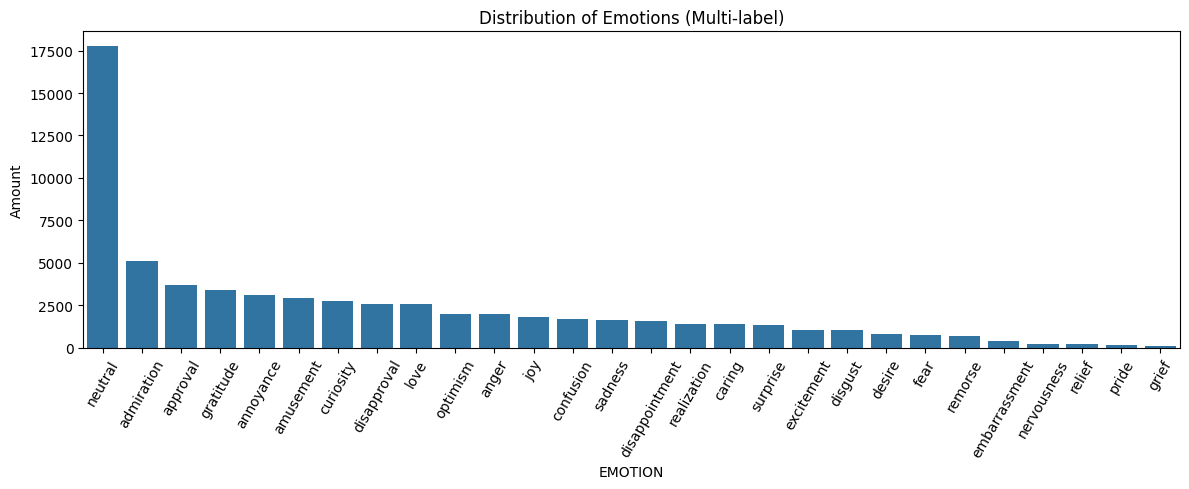

In [179]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

emotion_counts = df[emotions].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=60)
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

In [180]:
df.to_csv("../data/treated/go_emotions_treated.csv", index=False)

# (3) PlayStoreReviews

In [17]:
df = pd.read_csv('../data/08_PlayStoreReviews.csv')
df.drop(columns=['reviewId', 'app_name'], inplace=True)
print(df.shape)
df.head(3)

(3011, 3)


,content,sentiment_polarity,sentiment
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness
2,app bom prát fácil entend porém algum vend man...,positive,sadness


In [18]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'content')
df.rename(columns={"sentiment": 'EMOTION'}, inplace=True)
df.rename(columns={"sentiment_polarity": 'SENTIMENT'}, inplace=True)
print(df.shape)
df.head(3)

(3011, 8)


,content,SENTIMENT,EMOTION,UNCLEAN_TEXT,BASE_TEXT,TEXT_NO_STOP,TEXT_LEMMA,CLEAN_TEXT
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness,app shope razoá apes fácil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness,app bem otimiz fácil visual produt ped rastrei...,app bem otimiz facil visual produt ped rastrei...,app otimiz facil visual produt ped rastrei int...,app bem otimiz facil visual produt ped rastrar...,app otimiz facil visual produt ped rastrar int...
2,app bom prát fácil entend porém algum vend man...,positive,sadness,app bom prát fácil entend porém algum vend man...,app bom prat facil entend porem algum vend man...,app prat facil entend porem algum vend mand pr...,app bom prat facil entend porem algum vend man...,app prat facil entend porem algum vend mand pr...


In [19]:
n_nan = df['BASE_TEXT'].isna().sum()

n_empty = (df['BASE_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['BASE_TEXT'])
df = df[df['BASE_TEXT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 1
Total problemáticos: 1
(3010, 8)


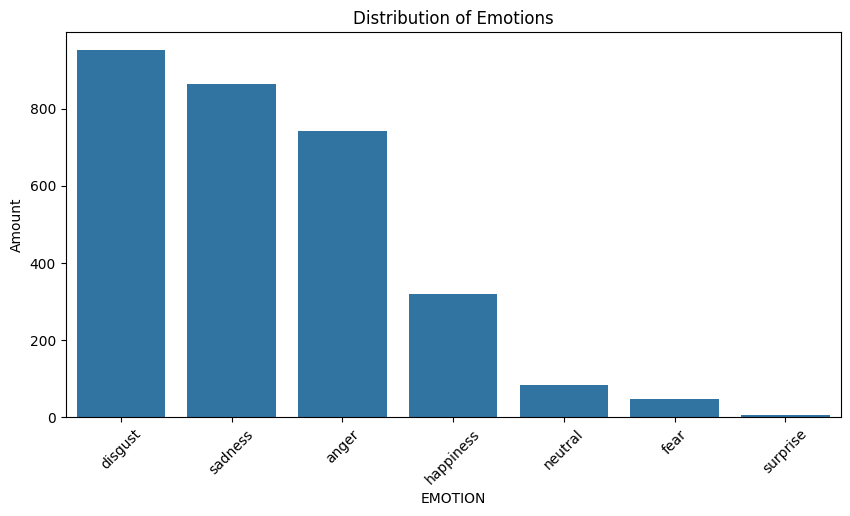

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

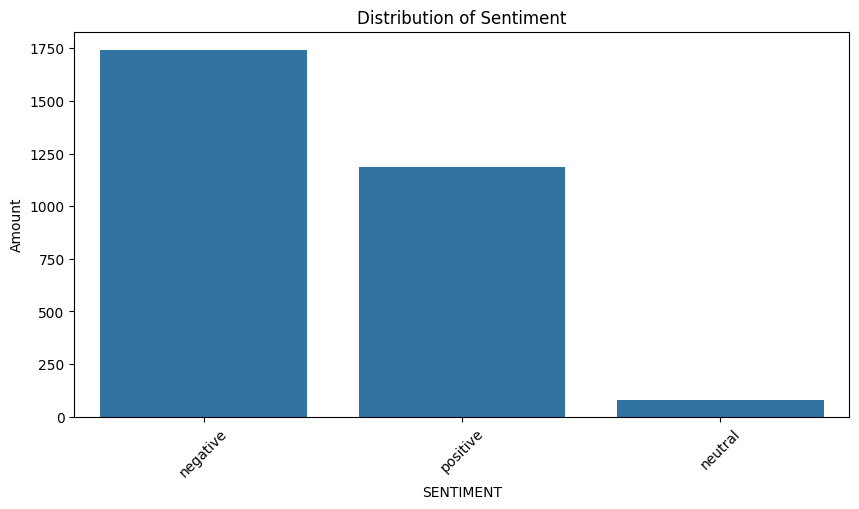

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.SENTIMENT.value_counts().index, y=df.SENTIMENT.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Sentiment")
plt.show()

In [22]:
df.to_csv("../data/treated/play_store_reviews_treated.csv", index=False)